### Model Training v2

Loads the existing FastText embeddings and preprocessed data, then trains the model with improvements to boost fake-class recall.

In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from gensim.models import FastText
from nltk.tokenize import word_tokenize
from torch.utils.data import DataLoader
from dataset_class.job_post_dataset import JobPostingDataset
from model_construction.model import FakeJobDetector
import os, json, pickle
import math
import seaborn as sb
import matplotlib.pyplot as plt


#Load preprocessed data
combined_df = pd.read_csv("./data/clean/fake_job_postings_ALL.csv")

numeric_cols = [
    "telecommuting", "missing_count", "total_text_len", "company_profile_len",
    "description_len", "requirements_len", "benefits_len",
    "company_profile_word_count", "description_word_count",
    "requirements_word_count", "benefits_word_count",
    "salary_provided", "has_company_profile", "vague_location",
    "has_company_logo", "has_questions"
]

print(f"Dataset: {combined_df.shape[0]} rows, {combined_df.shape[1]} cols")
print(f"Class balance: {combined_df['fraudulent'].value_counts().to_dict()}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Iris\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Iris\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Iris\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Iris\anaconda3\Lib\site-packages

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Iris\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Iris\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Iris\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Iris\anaconda3\Lib\site-packages

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Dataset: 13485 rows, 18 cols
Class balance: {0: 12799, 1: 686}


In [2]:
#Train / Val / Test split (80/10/10, stratified so same proportion of fraudulent vs non-fraudulent in each set)
train_data, temp_data = train_test_split(
    combined_df, test_size=0.2, random_state=42, stratify=combined_df['fraudulent']
)
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_data['fraudulent']
)

X_train_text    = train_data['full_text'].tolist()
X_train_numeric = train_data[numeric_cols].values.astype(np.float32)
y_train         = train_data['fraudulent'].values.tolist()

X_val_text      = val_data['full_text'].tolist()
X_val_numeric   = val_data[numeric_cols].values.astype(np.float32)
y_val           = val_data['fraudulent'].values.tolist()

X_test_text     = test_data['full_text'].tolist()
X_test_numeric  = test_data[numeric_cols].values.astype(np.float32)
y_test          = test_data['fraudulent'].values.tolist()

print(f"Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")

Train: 10788, Val: 1348, Test: 1349


In [3]:
#Scale non-binary numeric features
non_binary_cols = [
    "missing_count", "total_text_len", "company_profile_len", "description_len",
    "requirements_len", "benefits_len", "company_profile_word_count",
    "description_word_count", "requirements_word_count", "benefits_word_count"
]
non_binary_indices = [numeric_cols.index(col) for col in non_binary_cols]

scaler = StandardScaler()
X_train_numeric[:, non_binary_indices] = scaler.fit_transform(X_train_numeric[:, non_binary_indices])
X_val_numeric[:,   non_binary_indices] = scaler.transform(X_val_numeric[:,   non_binary_indices])
X_test_numeric[:,  non_binary_indices] = scaler.transform(X_test_numeric[:,  non_binary_indices])

In [4]:
#Load pretrained FastText embeddings
fasttext_model = FastText.load("./optimal_fasttext.bin")
print(f"FastText vocab: {len(fasttext_model.wv)} words, {fasttext_model.wv.vector_size}-dim")

FastText vocab: 22094 words, 100-dim


In [5]:
CACHE_DIR = "./data/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

tok_cache   = os.path.join(CACHE_DIR, "tokenized_splits.pkl")
vocab_cache = os.path.join(CACHE_DIR, "vocab.json")

if os.path.exists(tok_cache) and os.path.exists(vocab_cache):
    #Load cached tokenized data
    print("Loading cached tokenized data...")
    with open(tok_cache, "rb") as f:
        cached = pickle.load(f)
    train_texts_tok = cached["train"]
    val_texts_tok   = cached["val"]
    test_texts_tok  = cached["test"]

    with open(vocab_cache, "r") as f:
        vocab = json.load(f)

    print(f"Vocab size: {len(vocab)} (loaded from cache)")
else:
    #Tokenize and encode from scratch
    print("Tokenizing (first run, will be cached)...")
    train_tk = [word_tokenize(text.lower()) for text in X_train_text]
    val_tk   = [word_tokenize(text.lower()) for text in X_val_text]
    test_tk  = [word_tokenize(text.lower()) for text in X_test_text]

    # Build vocab from FastText (0=<unk>, 1=<pad>, 2+=words)
    vocab = {"<unk>": 0, "<pad>": 1}
    for idx, word in enumerate(fasttext_model.wv.index_to_key):
        vocab[word] = idx + 2

    def encode(tokens, vocab):
        return [vocab.get(t, 0) for t in tokens]

    train_texts_tok = [encode(s, vocab) for s in train_tk]
    val_texts_tok   = [encode(s, vocab) for s in val_tk]
    test_texts_tok  = [encode(s, vocab) for s in test_tk]

    # Save cache
    with open(tok_cache, "wb") as f:
        pickle.dump({"train": train_texts_tok, "val": val_texts_tok, "test": test_texts_tok}, f)
    with open(vocab_cache, "w") as f:
        json.dump(vocab, f)

    print(f"Vocab size: {len(vocab)} (saved to cache)")

Loading cached tokenized data...
Vocab size: 22096 (loaded from cache)


In [6]:
#Create Datasets and DataLoader
MAX_LEN    = 2048
BATCH_SIZE = 64
torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_dataset = JobPostingDataset(train_texts_tok, X_train_numeric, y_train, max_len=MAX_LEN)
val_dataset   = JobPostingDataset(val_texts_tok,   X_val_numeric,   y_val,   max_len=MAX_LEN)
test_dataset  = JobPostingDataset(test_texts_tok,  X_test_numeric,  y_test,  max_len=MAX_LEN)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_dataloader)}, Val: {len(val_dataloader)}, Test: {len(test_dataloader)}")

Train batches: 169, Val: 22, Test: 22


In [7]:
#Build embedding matrix from FastText
vocab_size = len(vocab)
embed_dim  = fasttext_model.wv.vector_size

embedding_matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)
for word, idx in vocab.items():
    if word in fasttext_model.wv:
        embedding_matrix[idx] = fasttext_model.wv[word]

pretrained_embeddings = torch.tensor(embedding_matrix, dtype=torch.float)
print(f"Embedding matrix: {pretrained_embeddings.shape}")

Embedding matrix: torch.Size([22096, 100])


In [8]:
#Instantiate model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FakeJobDetector(
    vocab_size             = vocab_size,
    embed_dim              = embed_dim,
    gru_hidden_dim         = 64,
    num_numerical_features = X_train_numeric.shape[1],
    num_hidden_dim         = 32,
    pretrained_embeddings  = pretrained_embeddings,
    device                 = device,
)
print(f"Device: {device}")
print(model)
print("cuda available:", torch.cuda.is_available())

num_real = sum(1 for y in y_train if y == 0)
num_fake = sum(1 for y in y_train if y == 1)
print(f"Num real: {num_real}, Num fake: {num_fake}")

Device: cuda
FakeJobDetector(
  (embedding): Embedding(22096, 100, padding_idx=1)
  (bigru): BiGRUBlock(
    (gru): GRU(100, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  )
  (attention): MultiHeadAttentionPooling(
    (heads): ModuleList(
      (0-1): 2 x Linear(in_features=128, out_features=1, bias=True)
    )
    (projection): Linear(in_features=256, out_features=128, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (numerical): NumericalBlock(
    (layers): Sequential(
      (0): Linear(in_features=16, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=32, out_features=32, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Linear(in_features=160, out_features=1, bias=True)
)
cuda available: True
Num real: 10239, Num fake: 549


In [ ]:
#Train
num_real = sum(1 for y in y_train if y == 0)
num_fake = sum(1 for y in y_train if y == 1)

train_losses, val_losses, train_accuracy, val_accuracy = model.fit(
    dataloader     = train_dataloader,
    val_dataloader = val_dataloader,
    num_epochs     = 20,
    learning_rate  = 1e-3,
    save_path      = "best_model_v5.pt",
    #pos_weight     = 3.0, #math.sqrt(num_real / num_fake), #rea/fake is 18.6, sqrt is 4.3
)


Epoch 1/20 | Train Loss: 0.0481 | Val Loss: 0.0356
  ✅ Best model saved (val_loss=0.0356)
Epoch 2/20 | Train Loss: 0.0340 | Val Loss: 0.0361
  ⚠️ No improvement (best_val_loss=0.0356)
Epoch 3/20 | Train Loss: 0.0306 | Val Loss: 0.0335
  ✅ Best model saved (val_loss=0.0335)
Epoch 4/20 | Train Loss: 0.0246 | Val Loss: 0.0256
  ✅ Best model saved (val_loss=0.0256)
Epoch 5/20 | Train Loss: 0.0209 | Val Loss: 0.0226
  ✅ Best model saved (val_loss=0.0226)
Epoch 6/20 | Train Loss: 0.0179 | Val Loss: 0.0169
  ✅ Best model saved (val_loss=0.0169)
Epoch 7/20 | Train Loss: 0.0160 | Val Loss: 0.0193
  ⚠️ No improvement (best_val_loss=0.0169)
Epoch 8/20 | Train Loss: 0.0155 | Val Loss: 0.0162
  ✅ Best model saved (val_loss=0.0162)
Epoch 9/20 | Train Loss: 0.0170 | Val Loss: 0.0209
  ⚠️ No improvement (best_val_loss=0.0162)
Epoch 10/20 | Train Loss: 0.0160 | Val Loss: 0.0256
  ⚠️ No improvement (best_val_loss=0.0162)
Epoch 11/20 | Train Loss: 0.0144 | Val Loss: 0.0254
  ⚠️ No improvement (best_val_l

In [10]:
#Evaluate on test set
for threshold in [0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.7, 0.8]:
    print(f"\n--- Threshold: {threshold} ---")
    model.evaluate(test_dataloader, threshold=threshold)


--- Threshold: 0.2 ---
              precision    recall  f1-score   support

        Real       0.99      0.93      0.96      1280
        Fake       0.40      0.91      0.56        69

    accuracy                           0.93      1349
   macro avg       0.70      0.92      0.76      1349
weighted avg       0.96      0.93      0.94      1349


--- Threshold: 0.3 ---
              precision    recall  f1-score   support

        Real       0.99      0.96      0.98      1280
        Fake       0.57      0.87      0.69        69

    accuracy                           0.96      1349
   macro avg       0.78      0.92      0.83      1349
weighted avg       0.97      0.96      0.96      1349


--- Threshold: 0.4 ---
              precision    recall  f1-score   support

        Real       0.99      0.97      0.98      1280
        Fake       0.64      0.87      0.74        69

    accuracy                           0.97      1349
   macro avg       0.82      0.92      0.86      1349
we

### Model evaulation

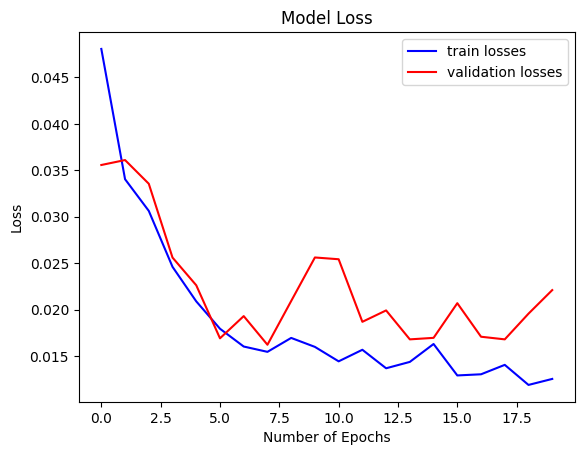

In [ ]:
plt.plot(train_losses, color='b', label="train losses")
plt.plot(val_losses, color='r', label="validation losses")
plt.title("Model Loss")
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(train_accuracy, color='b', label="train accuracy")
plt.plot(val_accuracy, color='r', label="validation accuracy")
plt.title("Model Accuracy")
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
plt.plot(train_accuracy, color='b', label="train losses")
plt.plot(val_accuracy, color='r', label="validation losses")
plt.title("Model Accuracy")
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()